# Architecture of filters

So, the english is not very good, I will improve that

In [69]:
import itertools

import sympy as sy
import numpy as np

from sympy import Matrix
from scipy.linalg import circulant
from sympy.physics.quantum import TensorProduct

In [70]:
import fitz

from utils import plot_pdf, plot_pdf2col, symmetrical_cyclic_convolution, conv_circ_fft

In [71]:
from sympy import init_printing
init_printing(use_latex='png', forecolor='White', backcolor='Black')

In [72]:
doc = fitz.open('Blahut_2010_Fast algorithms for signal processing.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.

This tutorial not work with others vector sizes

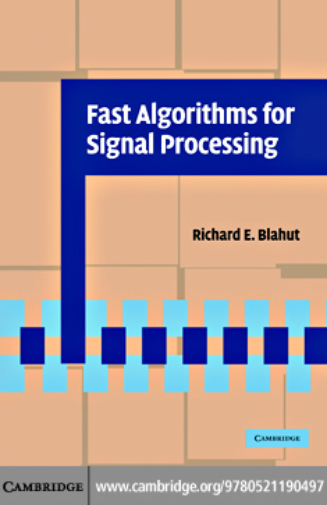

In [73]:
plot_pdf(doc[0], dpi=100)

## Polynomials

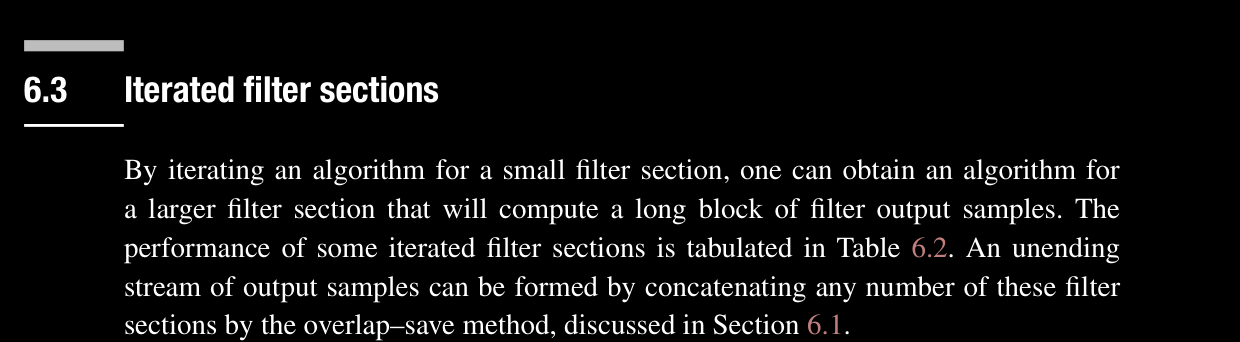

In [74]:
plot_pdf(doc[217], [.6, .78])

Size of vectors

In [75]:
size = 16

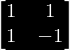

In [76]:
win = sy.Matrix([[1, 1], [1, -1]])
win

In [77]:
d2 = sy.Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(size))))
d2.T

In [78]:
g2 = sy.Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(size))))
g2.T

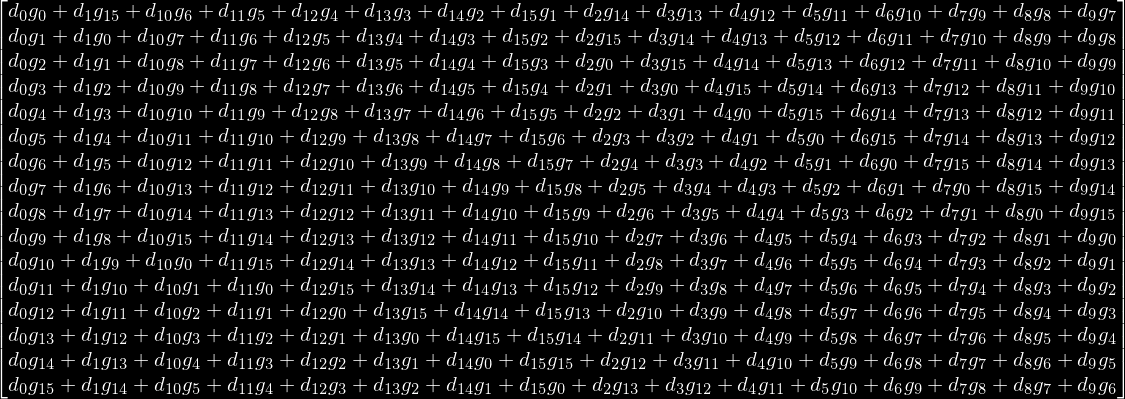

In [79]:
cc2 = sy.Matrix(symmetrical_cyclic_convolution(np.array(d2).reshape(-1), np.array(g2).reshape(-1)))
cc2

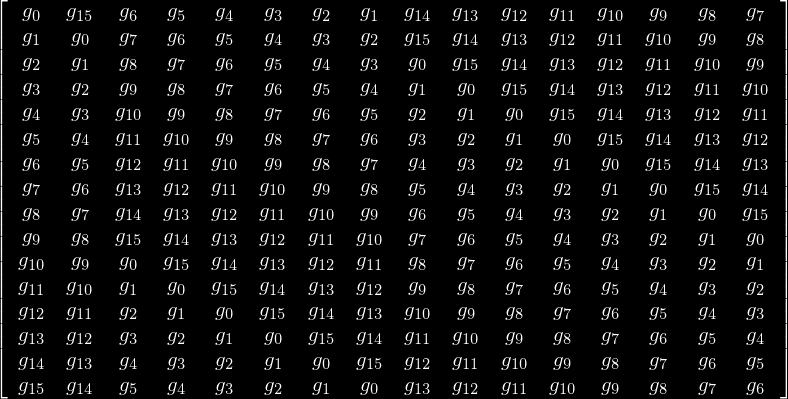

In [80]:
cc2_args = [[arg for mul in line.args for arg in mul.args if 'g' in arg.name] for line in cc2]
sy.Matrix(cc2_args)

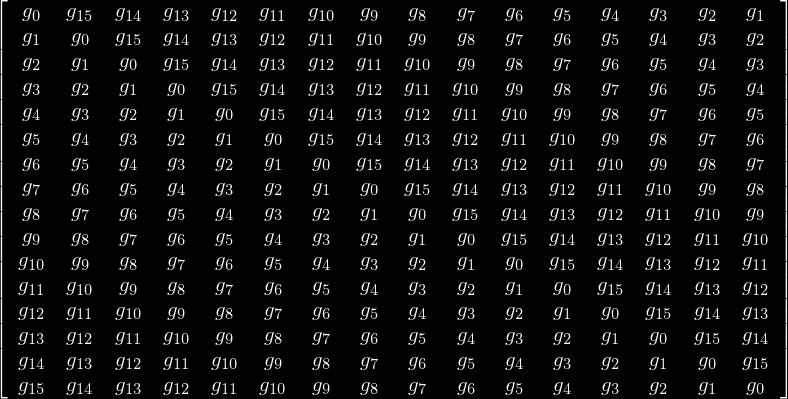

In [81]:
cc2_args = sy.Matrix(circulant(g2))
cc2_args

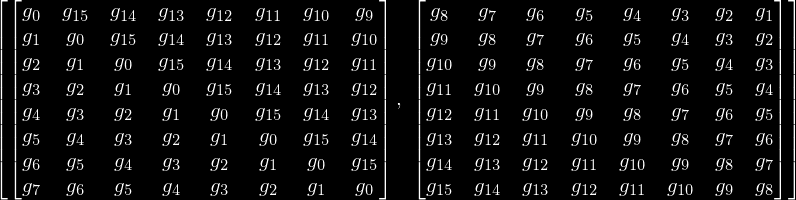

In [82]:
cc2_args = np.array(cc2_args)
g2m = [sy.Matrix(cc2_args[r:r+size//2, c:c+size//2].tolist()) for r in range(0, cc2_args.shape[0], size//2) for c in range(0, cc2_args.shape[1]//2, size//2)]
g2m

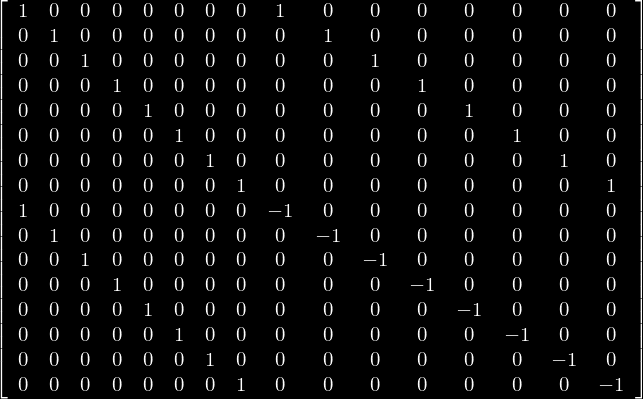

In [83]:
win2 = TensorProduct(win, sy.eye(size//2))
win2

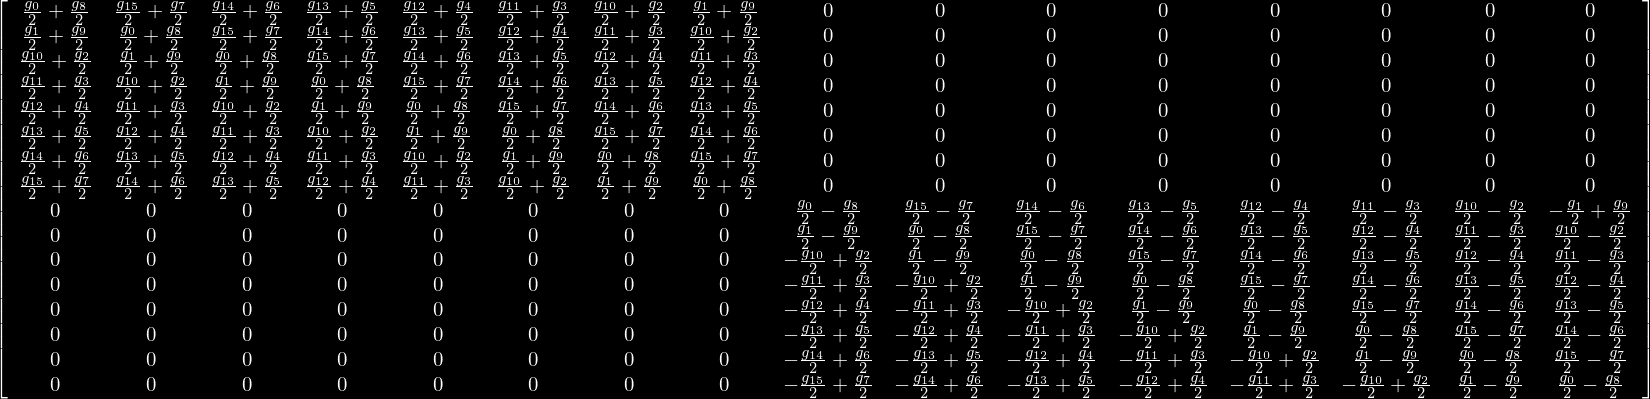

In [84]:
bg2 = sy.diag(*[
    g2m[0] + g2m[1], 
    g2m[0] - g2m[1]
])/2
bg2

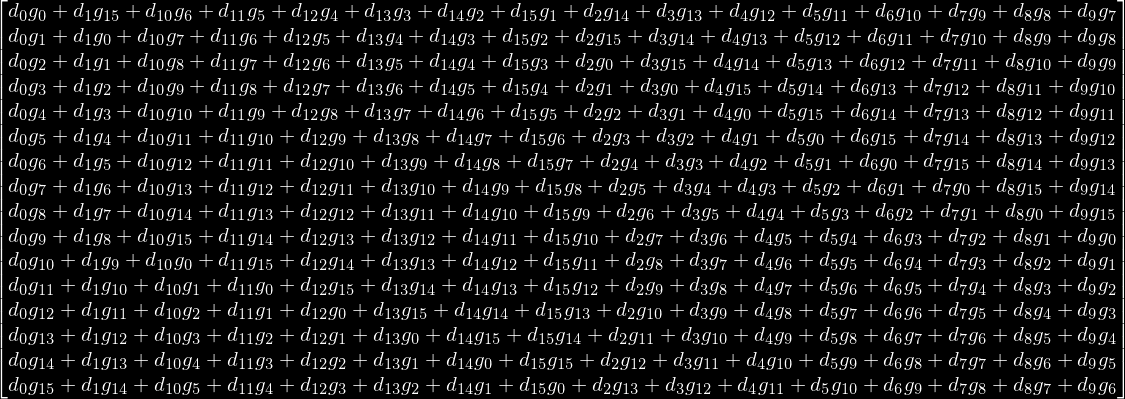

In [85]:
cc = sy.Matrix(symmetrical_cyclic_convolution(np.array(d2).reshape(-1), np.array(g2).reshape(-1)))
cc

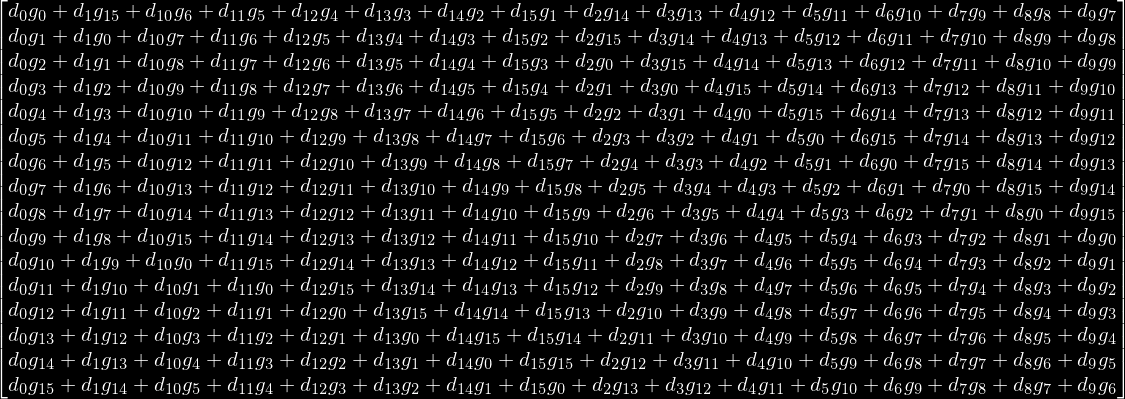

In [86]:
ssx = sy.MatMul(win2, bg2, win2, d2, evaluate=True)
ssx

In [87]:
np.all(np.array(cc) == np.array(ssx))

True

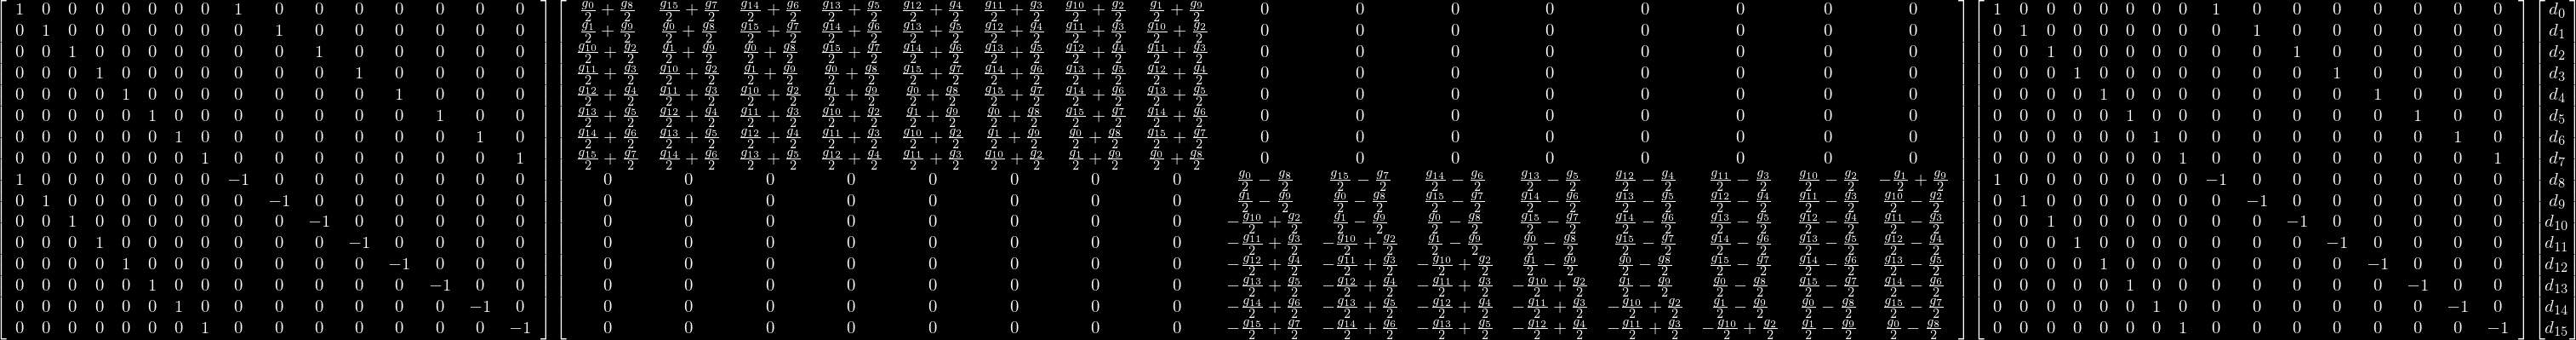

In [88]:
ssx = sy.MatMul(win2, bg2, win2, d2)
ssx

In [68]:
import random
val_d = [random.randint(0, 2**3) for r in range(size)]
val_g = [random.randint(0, 2**3) for r in range(size)]

In [45]:
subs_g = {k: v for k, v in zip(g2.flat(), val_g)}
subs_g

In [46]:
subs_d = {k: v for k, v in zip(g2.flat(), val_d)}
subs_d

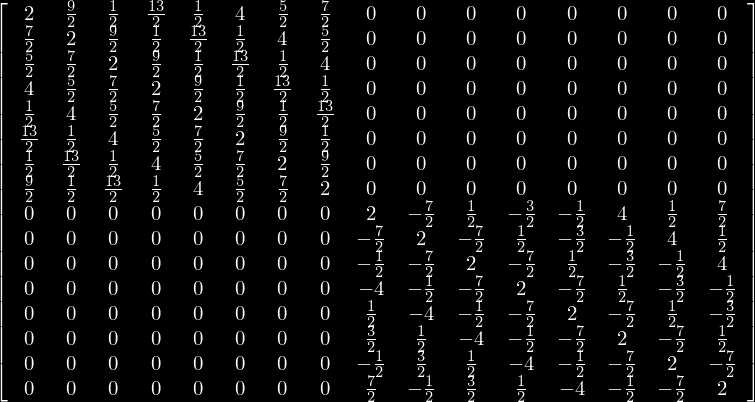

In [47]:
bg2_subs = bg2.subs(subs_g)
bg2_subs

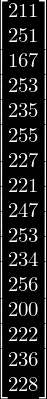

In [24]:
cout = sy.Matrix(symmetrical_cyclic_convolution(val_d, val_g))
cout

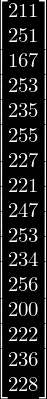

In [48]:
r = win2 * bg2_subs * win2 * sy.Matrix(val_d)
r

In [ ]:
np.all(np.array(cout) == np.array(r))

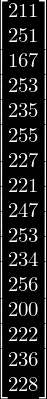

In [59]:
cfft =  sy.Matrix(conv_circ_fft(val_d, val_g).astype(int))
cfft

In [60]:
np.all(np.array(cfft) == np.array(r))

True

Testes como FFT

In [61]:
np.fft.fft(val_d)

array([77.         +0.j        ,  5.57679562 +2.55660167j,
        0.53553391 +0.05025253j,  5.24795761+12.02794903j,
        4.        +11.j        , 16.65153733 -3.87154591j,
       -6.53553391 -9.94974747j, -3.47629056 -1.34289327j,
        7.         +0.j        , -3.47629056 +1.34289327j,
       -6.53553391 +9.94974747j, 16.65153733 +3.87154591j,
        4.        -11.j        ,  5.24795761-12.02794903j,
        0.53553391 -0.05025253j,  5.57679562 -2.55660167j])

In [91]:
fft = (np.fft.fft(val_d))
fft.real - fft.imag

array([ 64.        , -16.9536454 ,  -3.41421356,  19.55128475,
        12.        ,  -1.70549221,  20.24264069,   5.20570084,
         4.        ,  12.61049964,  -0.58578644,   6.93399663,
         4.        , -13.95136204,  11.75735931,   4.30901778])

In [63]:
fft.real + fft.imag

array([ 77.        ,   8.13339729,   0.58578644,  17.27590664,
        15.        ,  12.77999143, -16.48528137,  -4.81918383,
         7.        ,  -2.13339729,   3.41421356,  20.52308324,
        -7.        ,  -6.77999143,   0.48528137,   3.02019396])

Se eu meter um número imaginário $i$ em alguns lugares oq será q acontece? 

In [67]:
winft = TensorProduct(win, win, win, win)

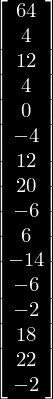

In [90]:
winft * sy.Matrix(val_d)